# ALS_LLRF_MTS test on ZCU208
---

The following results were captured when looping back all 8 DACs to 8 ADCs through equal-length cables.


### Preparation from a PYNQ 3.0.1 image:

Run installation script: `./pynq_llrf/install.sh`.

In [1]:
%cd /home/xilinx/jupyter_notebooks/pynq_llrf

/home/xilinx/jupyter_notebooks/pynq_llrf


In [2]:
from mimo_mts.overlay import MimoMtsOverlay
import numpy as np
import time
from mimo_mts.utils.plot import plot_complex_wfm_stack

%load_ext autoreload
%autoreload 2

In [3]:
ol = MimoMtsOverlay(config='ALS_LLRF_ZCU208')

Powering up and initializing analog frontend ...
Interrupt xpm_cdc_gen_0/dest_pulse created with number 2


In [4]:
ol

< MimoMtsOverlay >:
{ 'bitfile_name': PosixPath('/home/xilinx/jupyter_notebooks/pynq_llrf/mimo_mts/overlays/zcu208/als_llrf_mts.bit'),
  'board': Board(name='ZCU208',
                 active_adc_tiles=15,
                 active_dac_tiles=15,
                 max_adc_sampling_rate=5000000000.0,
                 max_dac_sampling_rate=7000000000.0,
                 converters_per_tile=2,
                 adc_ref_tile=225,
                 dac_ref_tile=230),
  'clk104_tcs': { 'lmk_tcs': PosixPath('/home/xilinx/jupyter_notebooks/pynq_llrf/mimo_mts/utils/clk104/LMK04828_500M_CLKin0_DIST.tcs'),
                  'lmxadc_tcs': PosixPath('/home/xilinx/jupyter_notebooks/pynq_llrf/mimo_mts/utils/clk104/LMX2594_4G.tcs'),
                  'lmxdac_tcs': PosixPath('/home/xilinx/jupyter_notebooks/pynq_llrf/mimo_mts/utils/clk104/LMX2594_4G.tcs')},
  'ioc': {'decimation': 2},
  'rfdc': { 'adc_decimation_factor': 8,
            'dac_interpolation_factor': 8,
            'mixer': { 'adc_mixer_mode': 3,


In [5]:
ol.clk104

< CLK104Config >:
  === LMK04828: ===
part            :    LMK04828B
SYSREF_FREQ     :        4.996 MHz
OSCout_FREQ     :      160.009 MHz
CLKin0_FREQ     :      499.640 MHz
CLKin1_FREQ     :      499.640 MHz
CLKin2_FREQ     :       76.800 MHz
CLKout0_FREQ    :      499.640 MHz
CLKout1_FREQ    :        4.996 MHz
CLKout2_FREQ    :      499.640 MHz
CLKout3_FREQ    :        4.996 MHz
CLKout4_FREQ    :      499.640 MHz
CLKout5_FREQ    :        4.996 MHz
CLKout6_FREQ    :      499.640 MHz
CLKout7_FREQ    :        4.996 MHz
CLKout8_FREQ    :      499.640 MHz
CLKout9_FREQ    :        4.996 MHz
CLKout10_FREQ   :      499.640 MHz
CLKout11_FREQ   :      499.640 MHz
CLKout12_FREQ   :      499.640 MHz
CLKout13_FREQ   :        4.996 MHz
CLKin_SEL_MODE  :       CLKin0
VCO_MUX         : CLKin1 (ext)
  === LMX2594 ADC: ===
part            :      LMX2594
Fosc_FREQ       :      499.640 MHz
FoutA_FREQ      :     3997.120 MHz
FoutB_FREQ      :     3997.120 MHz
Fpd_FREQ        :      249.820 MHz
Fvco_FREQ 

In [6]:
f_dsp_mhz = 250
trig_period = 125e6  # cycles of f_dsp_mhz

print(f"fclk0_mhz: {f_dsp_mhz} MHz")
print(f"trigger frequency: { f_dsp_mhz * 1e6 / trig_period:.2f} Hz")

fclk0_mhz: 250 MHz
trigger frequency: 2.00 Hz


# Configure trigger and DSP

In [7]:
ol.rf_control.register_map.trig_period = trig_period
ol.rf_control.register_map.trig_sel = 0  # internal trigger
ol.rf_control.register_map.trig_delay = 0
ol.rf_control.register_map.trig_divide = 1
ol.rf_control.register_map.dac_enable = 1
ol.rf_control.register_map.pulse_length = 4096
ol.rf_control.register_map.amp_loop_setpoint = 0

## Test IRQ

Note: Jupyter notebook refresh time of ~300ms limits the testing to 3Hz

In [8]:
async def wait_for_irq():
    irq = ol.write_done_irq
    t0 = time.perf_counter()
    while True:
        await irq.wait()
        t1 = time.perf_counter()
        print(f"IRQ!, time since last: {t1-t0:.6f} s")

In [9]:
import asyncio
loop = asyncio.get_event_loop()
task = loop.create_task(wait_for_irq())
try:
    loop.run_until_complete(task)
except KeyboardInterrupt:
    print("KeyboardInterrupt received. Stopping the loop.")
    task.cancel()

IRQ!, time since last: 0.000702 s
IRQ!, time since last: 0.233749 s
IRQ!, time since last: 0.733736 s
IRQ!, time since last: 1.233726 s
IRQ!, time since last: 1.733743 s
IRQ!, time since last: 2.233750 s
IRQ!, time since last: 2.733744 s
IRQ!, time since last: 3.233746 s
IRQ!, time since last: 3.733746 s
IRQ!, time since last: 4.233746 s
IRQ!, time since last: 4.733758 s
IRQ!, time since last: 5.233749 s
IRQ!, time since last: 5.733762 s
IRQ!, time since last: 6.233758 s
IRQ!, time since last: 6.733760 s
IRQ!, time since last: 7.233764 s
KeyboardInterrupt received. Stopping the loop.


In [10]:
fs = ol.adc_sampling_rate
fs = fs / 8  # after decimation
start = 210 # start of the signal, measured
print(f'RF loop back latency: {start / fs * 1e9} ns')

RF loop back latency: 420.0 ns


In [11]:
dac_i = np.ones(ol.dac_player.size//2, dtype=np.int16) * 32767
dac_q = np.zeros_like(dac_i)
pulse_length_ns = 256  # short pulse
n_samples = int(pulse_length_ns / 1e9 * fs)
dac_i[n_samples:] = 0
ol.write_dac_iq_buf(dac_i, dac_q)

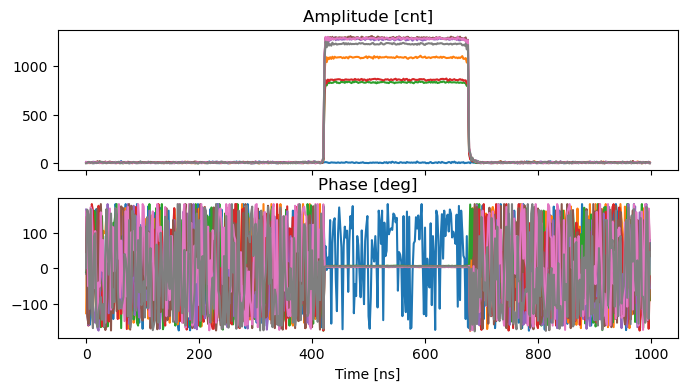

In [13]:
darray_i, darray_q = ol.capture_adc_iq_buf();
cdata = darray_i + 1j*darray_q
plot_complex_wfm_stack(cdata[:, :500], fs=fs, mode='ap', legend=False)

In [14]:
def get_dsp_waveform(ol=ol):
    """
    Get the DSP waveform from the ADC buffer.
    Average ADC data by 2 samples, as the same to the LLRF DSP,
    equivalent to a low pass filter to get base band signal.
    """
    darray_i, darray_q = ol.capture_adc_iq_buf()
    cdata = darray_i + 1j*darray_q
    return cdata.reshape(8, -1, 2).mean(axis=2)

# Disable dac buffer, use llrf amplitude setpoint for CW signal

In [15]:
ol.dac_player[:] = np.zeros(ol.dac_player.size, dtype=np.int16)

In [16]:
ol.rf_control.register_map.amp_loop_setpoint = 32767 / ol.rf_control.tx_gain
ol.rf_control.register_map.phs_loop_setpoint = 0

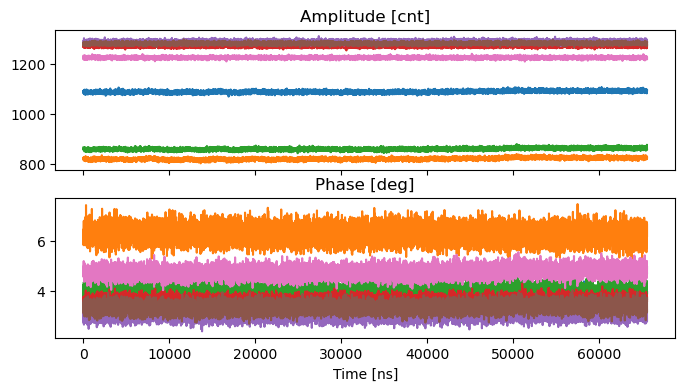

In [18]:
cdata_dsp = get_dsp_waveform()
plot_complex_wfm_stack(cdata_dsp[1:], fs=fs/2, mode='ap')

# Check LLRF pulsing mode

In [19]:
ol.rf_control.register_map.dac_enable.pulse_enable=1
ol.rf_control.register_map.pulse_length=100

Expect 4 ns * 100 = 400 ns pulse length

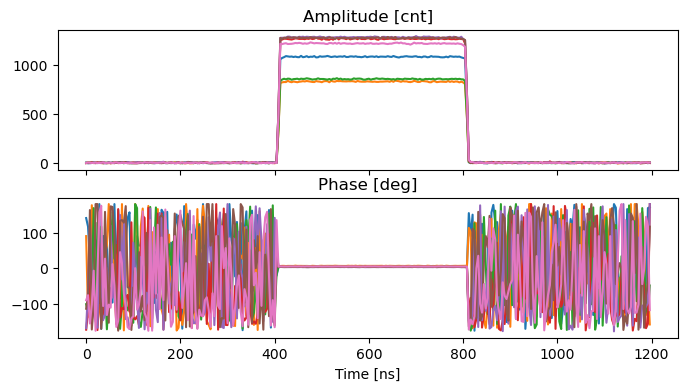

In [20]:
cdata_dsp = get_dsp_waveform()
plot_complex_wfm_stack(cdata_dsp[1:, :300], fs=fs/2, mode='ap')

# Plot DAC waveform

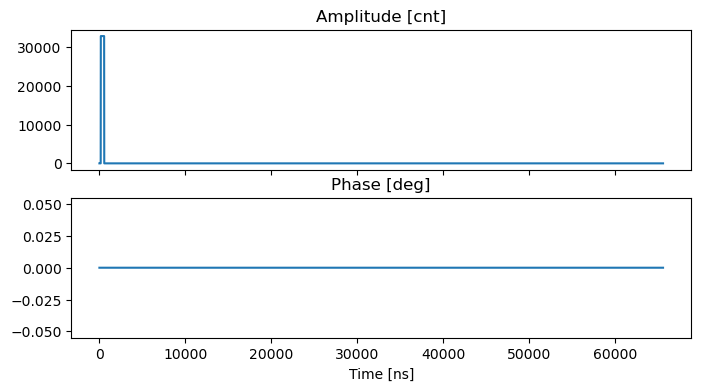

In [21]:
darray_i, darray_q = ol.capture_dac_iq_buf()
dac_c = darray_i + 1j*darray_q
plot_complex_wfm_stack(np.array([dac_c]), fs=fs, mode='ap')